# Week 4: Machine Learning Model Development and Evaluation

## Superstore Sales Dataset

### Objective

The objective of this Week 4 project is to build, train, and evaluate a
machine learning classification model using the Superstore Sales dataset.

The model will predict whether an order is profitable or non-profitable
using business-related features such as Sales, Quantity, Discount,
Category, Segment, and Region.

### Target Variable

A binary target variable named **Profitable** will be created:

- **1** = Profit > 0
- **0** = Profit <= 0

The original Profit column will not be used as an input feature because
doing so would introduce data leakage.

### Machine Learning Workflow

1. Data loading and inspection
2. Target variable creation
3. Feature selection
4. Data preprocessing
5. Train-test split
6. Model training
7. Model evaluation
8. Confusion matrix
9. ROC curve and AUC
10. Error analysis and model limitations

In [12]:
%pip install scikit-learn

Defaulting to user installation because normal site-packages is not writeable
You should consider upgrading via the '/Library/Developer/CommandLineTools/usr/bin/python3 -m pip install --upgrade pip' command.
Note: you may need to restart the kernel to use updated packages.


In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    roc_curve,
    roc_auc_score
)

import warnings
warnings.filterwarnings("ignore")

print("Machine learning libraries imported successfully!")

Machine learning libraries imported successfully!


In [14]:
# Load the Superstore Sales dataset

file_path = "../dataset/superstore_sales.xls"

df = pd.read_excel(file_path)

print("Dataset loaded successfully!")
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

display(df.head())

Dataset loaded successfully!
Rows: 10194
Columns: 21


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country/Region,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,US-2023-103800,2023-01-03,2023-01-07,Standard Class,DP-13000,Darren Powers,Consumer,United States,Houston,...,77095,Central,OFF-PA-10000174,Office Supplies,Paper,"Message Book, Wirebound, Four 5 1/2"" X 4"" Form...",16.448,2,0.2,5.5512
1,2,US-2023-112326,2023-01-04,2023-01-08,Standard Class,PO-19195,Phillina Ober,Home Office,United States,Naperville,...,60540,Central,OFF-BI-10004094,Office Supplies,Binders,GBC Standard Plastic Binding Systems Combs,3.540,2,0.8,-5.4870
2,3,US-2023-112326,2023-01-04,2023-01-08,Standard Class,PO-19195,Phillina Ober,Home Office,United States,Naperville,...,60540,Central,OFF-LA-10003223,Office Supplies,Labels,Avery 508,11.784,3,0.2,4.2717
3,4,US-2023-112326,2023-01-04,2023-01-08,Standard Class,PO-19195,Phillina Ober,Home Office,United States,Naperville,...,60540,Central,OFF-ST-10002743,Office Supplies,Storage,SAFCO Boltless Steel Shelving,272.736,3,0.2,-64.7748
4,5,US-2023-141817,2023-01-05,2023-01-12,Standard Class,MB-18085,Mick Brown,Consumer,United States,Philadelphia,...,19143,East,OFF-AR-10003478,Office Supplies,Art,Avery Hi-Liter EverBold Pen Style Fluorescent ...,19.536,3,0.2,4.8840


In [3]:
# Create binary target variable

df["Profitable"] = (df["Profit"] > 0).astype(int)

print("Target variable created successfully!")
print("\nTarget distribution:")
print(df["Profitable"].value_counts())

print("\nTarget distribution (%):")
print((df["Profitable"].value_counts(normalize=True) * 100).round(2))

Target variable created successfully!

Target distribution:
Profitable
1    8228
0    1966
Name: count, dtype: int64

Target distribution (%):
Profitable
1    80.71
0    19.29
Name: proportion, dtype: float64


In [4]:
# Select features and target

features = [
    "Sales",
    "Quantity",
    "Discount",
    "Category",
    "Sub-Category",
    "Segment",
    "Region",
    "Ship Mode"
]

X = df[features].copy()
y = df["Profitable"].copy()

print("Features selected successfully!")
print("\nFeature columns:")
print(X.columns.tolist())

print("\nFeature data shape:", X.shape)
print("Target shape:", y.shape)

display(X.head())

Features selected successfully!

Feature columns:
['Sales', 'Quantity', 'Discount', 'Category', 'Sub-Category', 'Segment', 'Region', 'Ship Mode']

Feature data shape: (10194, 8)
Target shape: (10194,)


,Sales,Quantity,Discount,Category,Sub-Category,Segment,Region,Ship Mode
0,16.448,2,0.2,Office Supplies,Paper,Consumer,Central,Standard Class
1,3.540,2,0.8,Office Supplies,Binders,Home Office,Central,Standard Class
2,11.784,3,0.2,Office Supplies,Labels,Home Office,Central,Standard Class
3,272.736,3,0.2,Office Supplies,Storage,Home Office,Central,Standard Class
4,19.536,3,0.2,Office Supplies,Art,Consumer,East,Standard Class


In [5]:
# Split the dataset into training and testing sets

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Train-test split completed successfully!")
print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

print("\nTraining target distribution:")
print(y_train.value_counts())

print("\nTesting target distribution:")
print(y_test.value_counts())

Train-test split completed successfully!
Training samples: 8155
Testing samples: 2039

Training target distribution:
Profitable
1    6582
0    1573
Name: count, dtype: int64

Testing target distribution:
Profitable
1    1646
0     393
Name: count, dtype: int64


In [6]:
# Define numerical and categorical features

numeric_features = [
    "Sales",
    "Quantity",
    "Discount"
]

categorical_features = [
    "Category",
    "Sub-Category",
    "Segment",
    "Region",
    "Ship Mode"
]

# Create preprocessing pipeline

preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            StandardScaler(),
            numeric_features
        ),
        (
            "cat",
            OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=False
            ),
            categorical_features
        )
    ]
)

print("Preprocessing pipeline created successfully!")
print("Numerical features:", numeric_features)
print("Categorical features:", categorical_features)

Preprocessing pipeline created successfully!
Numerical features: ['Sales', 'Quantity', 'Discount']
Categorical features: ['Category', 'Sub-Category', 'Segment', 'Region', 'Ship Mode']


In [7]:
# Build complete machine learning pipeline

model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "classifier",
            LogisticRegression(
                max_iter=1000,
                class_weight="balanced",
                random_state=42
            )
        )
    ]
)

# Train the model
model.fit(X_train, y_train)

print("Logistic Regression model trained successfully!")

Logistic Regression model trained successfully!


In [8]:
# Make predictions on the test set

y_pred = model.predict(X_test)
y_pred_proba = model.predict_proba(X_test)[:, 1]

# Calculate evaluation metrics

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("Model Evaluation Results")
print("=" * 50)
print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1-Score : {f1:.4f}")

print("\nClassification Report")
print("=" * 50)
print(classification_report(
    y_test,
    y_pred,
    target_names=["Non-Profitable", "Profitable"]
))

Model Evaluation Results
Accuracy : 0.9117
Precision: 0.9822
Recall   : 0.9070
F1-Score : 0.9431

Classification Report
                precision    recall  f1-score   support

Non-Profitable       0.71      0.93      0.80       393
    Profitable       0.98      0.91      0.94      1646

      accuracy                           0.91      2039
     macro avg       0.84      0.92      0.87      2039
  weighted avg       0.93      0.91      0.92      2039



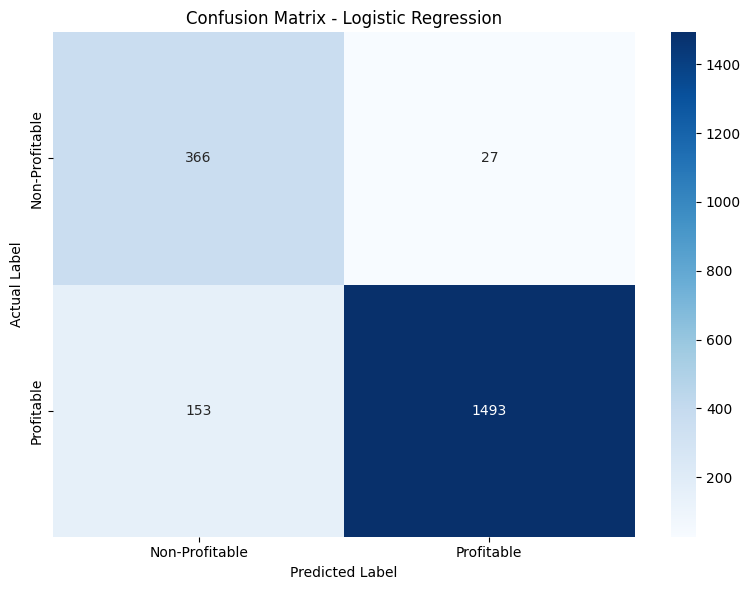

In [9]:
# Confusion Matrix

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8, 6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Non-Profitable", "Profitable"],
    yticklabels=["Non-Profitable", "Profitable"]
)

plt.title("Confusion Matrix - Logistic Regression")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")

plt.tight_layout()
plt.show()

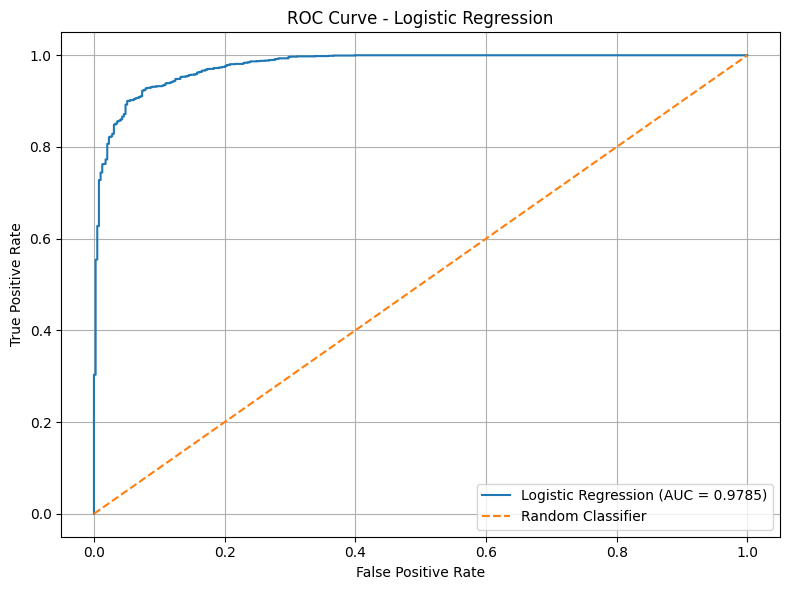

ROC-AUC Score: 0.9785


In [10]:
# ROC Curve and AUC Score

fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)
auc_score = roc_auc_score(y_test, y_pred_proba)

plt.figure(figsize=(8, 6))

plt.plot(
    fpr,
    tpr,
    label=f"Logistic Regression (AUC = {auc_score:.4f})"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random Classifier"
)

plt.title("ROC Curve - Logistic Regression")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

print(f"ROC-AUC Score: {auc_score:.4f}")

In [11]:
# Identify incorrectly classified observations

error_df = X_test.copy()

error_df["Actual"] = y_test.values
error_df["Predicted"] = y_pred

errors = error_df[error_df["Actual"] != error_df["Predicted"]]

print("Model Error Analysis")
print("=" * 50)
print("Total test observations:", len(y_test))
print("Incorrect predictions:", len(errors))
print("Error rate:", f"{len(errors) / len(y_test) * 100:.2f}%")

print("\nIncorrect predictions by actual class:")
print(errors["Actual"].value_counts())

display(errors.head(10))

Model Error Analysis
Total test observations: 2039
Incorrect predictions: 180
Error rate: 8.83%

Incorrect predictions by actual class:
Actual
1    153
0     27
Name: count, dtype: int64


,Sales,Quantity,Discount,Category,Sub-Category,Segment,Region,Ship Mode,Actual,Predicted
2269,29.304,3,0.2,Office Supplies,Storage,Consumer,West,Second Class,1,0
663,196.752,6,0.2,Technology,Accessories,Consumer,West,First Class,1,0
162,481.568,2,0.2,Furniture,Chairs,Corporate,West,Standard Class,1,0
952,6.800,1,0.2,Office Supplies,Supplies,Consumer,West,Standard Class,1,0
1678,5.544,7,0.2,Technology,Accessories,Corporate,Central,Standard Class,1,0
6992,285.552,2,0.2,Office Supplies,Storage,Consumer,East,Standard Class,1,0
7832,23.760,3,0.2,Office Supplies,Supplies,Corporate,Central,Second Class,1,0
3516,323.136,4,0.2,Furniture,Chairs,Consumer,West,Same Day,1,0
7442,257.500,3,0.2,Furniture,Bookcases,Consumer,West,Standard Class,1,0
5243,544.008,3,0.2,Furniture,Chairs,Corporate,West,Standard Class,1,0


## Model Limitations and Possible Improvements

### Limitations

1. The target variable is imbalanced, with profitable orders representing
   a larger proportion of the dataset.
2. Logistic Regression assumes a relatively linear relationship between
   the input features and the log-odds of the target.
3. The model uses selected sales, discount, product, customer, and shipping
   features; additional business variables may improve prediction.
4. The analysis is based on historical Superstore sales data, so model
   performance may change when applied to different datasets or future
   business conditions.
5. Statistical association and model prediction should not be interpreted
   as proof that a particular feature directly causes profitability.

### Possible Improvements

- Compare Logistic Regression with Decision Tree, Random Forest, and
  Gradient Boosting models.
- Perform hyperparameter tuning using cross-validation.
- Engineer additional features such as order month, shipping duration,
  and sales-per-quantity.
- Evaluate models using multiple metrics, especially F1-score and ROC-AUC,
  rather than accuracy alone.
- Investigate class-balancing techniques such as SMOTE where appropriate.
- Perform feature importance analysis to understand the main drivers of
  model predictions.